# Lecture 07 — Decision Trees & Ensemble Learning

**Learning objectives**

- Define impurity measures (Gini, entropy, MSE) and information gain, and understand greedy CART splitting.
- Implement a CART classifier from scratch and verify it against `DecisionTreeClassifier`.
- Diagnose overfitting in trees and prune with minimal cost-complexity pruning.
- Derive the variance-reduction effect of bagging and explain why Random Forests decorrelate trees.
- Use out-of-bag (OOB) error and contrast impurity-based with permutation feature importance.
- Derive AdaBoost's weight update from exponential loss and implement it from scratch with stumps.
- Understand gradient boosting as functional gradient descent and implement a small GBM for regression.
- Use modern tools (`HistGradientBoosting`, stacking, voting) and compare ensembles empirically.

**Prerequisites**

- Bias–variance trade-off and cross-validation ([`04_model_evaluation_and_selection.ipynb`](04_model_evaluation_and_selection.ipynb)).
- Linear and logistic regression, gradient descent ([`02_linear_regression.ipynb`](02_linear_regression.ipynb), [`03_logistic_regression_and_classification.ipynb`](03_logistic_regression_and_classification.ipynb)).
- Lecture 06 ([`06_support_vector_machines.ipynb`](06_support_vector_machines.ipynb)) for the margin / surrogate-loss viewpoint used in boosting.

**Contents**

1. Decision trees: impurity and information gain
2. CART from scratch
3. Visualising trees and decision boundaries
4. Overfitting and cost-complexity pruning
5. Bagging and variance reduction
6. Random Forests: OOB error and feature importance
7. AdaBoost: derivation and from-scratch implementation
8. Gradient boosting as functional gradient descent
9. HistGradientBoosting, voting and stacking
10. Comparison table
11. Pitfalls & practical tips
12. Exercises
13. Summary and further reading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, warnings
from sklearn.datasets import load_breast_cancer, load_iris, load_diabetes, make_moons, make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier, AdaBoostClassifier,
                              GradientBoostingRegressor, GradientBoostingClassifier,
                              HistGradientBoostingClassifier, VotingClassifier, StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, mean_squared_error

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 4.5)
np.random.seed(42)
rng = np.random.default_rng(42)

## 1. Decision trees: impurity and information gain

A decision tree recursively partitions the input space into axis-aligned boxes $R_1,\dots,R_M$ and predicts a constant in each:
$$
f(\mathbf{x}) = \sum_{m=1}^M c_m\,\mathbb{1}[\mathbf{x}\in R_m].
$$
Finding the optimal tree is NP-hard, so **CART** (Breiman et al., 1984) grows it greedily: at each node, choose the feature $j$ and threshold $t$ that most decrease an impurity measure, then recurse on $\{x_j\le t\}$ and $\{x_j>t\}$.

### 1.1 Impurity measures for classification

Let $p_k$ be the fraction of class $k$ among the $n_m$ samples at node $m$.

- **Misclassification error:** $1 - \max_k p_k$.
- **Gini index:** $G = \sum_k p_k(1-p_k) = 1 - \sum_k p_k^2$ — the probability of misclassifying a random sample if we label it randomly according to $p$.
- **Entropy:** $H = -\sum_k p_k\log_2 p_k$ — expected number of bits to encode the class.

All are zero for pure nodes and maximal for uniform $p$. Gini and entropy are *strictly concave*, which guarantees that any non-trivial split weakly decreases weighted impurity; misclassification error is piecewise linear and often fails to reward splits that improve purity without changing the majority class.

### 1.2 Information gain

For a split of node $m$ into children $L$, $R$:
$$
\Delta I = I(m) - \frac{n_L}{n_m}I(L) - \frac{n_R}{n_m}I(R).
$$
With entropy, $\Delta I$ is the **information gain** $= $ mutual information between the split indicator and the label (on the node's samples).

### 1.3 Regression trees

For regression the leaf value that minimises squared error is the mean, $c_m = \bar y_m$, and the impurity is the **within-node MSE** $I(m) = \frac{1}{n_m}\sum_{i\in m}(y_i-\bar y_m)^2$. The best split therefore maximises the reduction in residual sum of squares.

### 1.4 Complexity

Sorting each feature once per node, a split search costs $O(d\,n_m\log n_m)$; a balanced tree of depth $\log n$ therefore costs $O(d\,n\log^2 n)$ to grow. Prediction is $O(\text{depth})$.

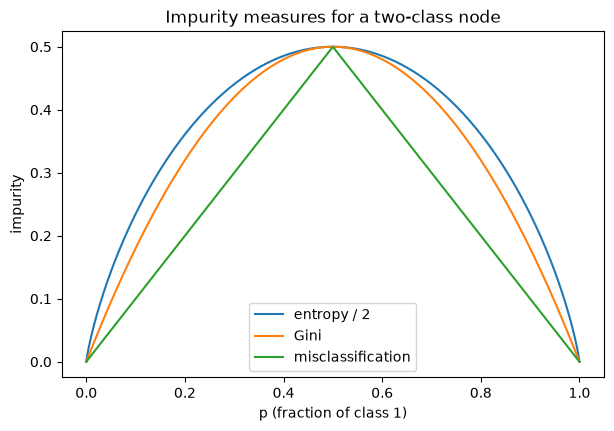

In [2]:
p = np.linspace(1e-6, 1 - 1e-6, 400)
gini = 2 * p * (1 - p)
ent = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))
mis = 1 - np.maximum(p, 1 - p)
plt.plot(p, ent / 2, label="entropy / 2")
plt.plot(p, gini, label="Gini")
plt.plot(p, mis, label="misclassification")
plt.xlabel("p (fraction of class 1)"); plt.ylabel("impurity")
plt.title("Impurity measures for a two-class node"); plt.legend(); plt.show()

**Worked example (why concavity matters).** A parent node has 400 samples of each class. Split A: $(300, 100)$ / $(100, 300)$. Split B: $(200, 400)$ / $(200, 0)$. Both have misclassification error $0.25$, but Gini and entropy prefer B because it creates a *pure* node.

In [3]:
def gini_impurity(counts):
    p = np.asarray(counts, float) / np.sum(counts)
    return 1 - np.sum(p ** 2)

def entropy(counts):
    p = np.asarray(counts, float) / np.sum(counts)
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

def misclass(counts):
    p = np.asarray(counts, float) / np.sum(counts)
    return 1 - p.max()

def gain(parent, children, imp):
    n = np.sum(parent)
    return imp(parent) - sum(np.sum(c) / n * imp(c) for c in children)

parent = [400, 400]
for name, ch in [("A", [[300, 100], [100, 300]]), ("B", [[200, 400], [200, 0]])]:
    print(f"split {name}: gain Gini={gain(parent, ch, gini_impurity):.4f}  "
          f"entropy={gain(parent, ch, entropy):.4f}  misclass={gain(parent, ch, misclass):.4f}")

split A: gain Gini=0.1250  entropy=0.1887  misclass=0.2500
split B: gain Gini=0.1667  entropy=0.3113  misclass=0.2500


## 2. CART from scratch

Algorithm for a node with data $(X, y)$:

1. If a stopping criterion holds (depth $=$ `max_depth`, $n < $ `min_samples_split`, node is pure, or no split improves impurity), make a **leaf** storing the class distribution.
2. Otherwise, for every feature $j$, sort the node's samples by $x_j$ and evaluate every threshold halfway between consecutive distinct values. Using cumulative class counts, the weighted Gini of all $n_m-1$ candidate splits for a feature is computed in $O(n_m)$ after sorting.
3. Pick the best $(j,t)$ satisfying `min_samples_leaf`, split, and recurse.

The implementation below is vectorised over thresholds via cumulative sums.

In [4]:
class Node:
    __slots__ = ("feature", "threshold", "left", "right", "value")
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature, self.threshold, self.left, self.right, self.value = feature, threshold, left, right, value

class CARTClassifier:
    # Binary-split classification tree with Gini impurity (from scratch).
    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1):
        self.max_depth = max_depth if max_depth is not None else np.inf
        self.min_samples_split, self.min_samples_leaf = min_samples_split, min_samples_leaf

    def fit(self, X, y):
        self.classes_, y_enc = np.unique(y, return_inverse=True)
        self.K_ = len(self.classes_)
        self.n_nodes_ = 0
        self.root_ = self._grow(X, y_enc, depth=0)
        return self

    def _best_split(self, X, y):
        n, d = X.shape
        best = (None, None, np.inf)                    # (feature, threshold, weighted impurity)
        msl = self.min_samples_leaf
        for j in range(d):
            order = np.argsort(X[:, j], kind="stable")
            xs, ys = X[order, j], y[order]
            onehot = np.eye(self.K_)[ys]               # (n, K)
            left_counts = np.cumsum(onehot, axis=0)[:-1]   # counts for split after position i
            right_counts = onehot.sum(0) - left_counts
            nl = np.arange(1, n); nr = n - nl
            gini_l = 1 - ((left_counts / nl[:, None]) ** 2).sum(1)
            gini_r = 1 - ((right_counts / nr[:, None]) ** 2).sum(1)
            weighted = (nl * gini_l + nr * gini_r) / n
            valid = (xs[1:] > xs[:-1]) & (nl >= msl) & (nr >= msl)   # only between distinct values
            if not valid.any():
                continue
            weighted = np.where(valid, weighted, np.inf)
            i = np.argmin(weighted)
            if weighted[i] < best[2]:
                best = (j, 0.5 * (xs[i] + xs[i + 1]), weighted[i])
        return best

    def _grow(self, X, y, depth):
        self.n_nodes_ += 1
        counts = np.bincount(y, minlength=self.K_)
        leaf = Node(value=counts / counts.sum())
        if depth >= self.max_depth or len(y) < self.min_samples_split or counts.max() == len(y):
            return leaf
        j, t, imp = self._best_split(X, y)
        if j is None or imp >= gini_impurity(counts) - 1e-12:   # no improving split
            return leaf
        mask = X[:, j] <= t
        return Node(j, t, self._grow(X[mask], y[mask], depth + 1),
                    self._grow(X[~mask], y[~mask], depth + 1))

    def _predict_one(self, x):
        node = self.root_
        while node.value is None:
            node = node.left if x[node.feature] <= node.threshold else node.right
        return node.value

    def predict_proba(self, X):
        return np.array([self._predict_one(x) for x in X])

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(1)]

In [5]:
Xbc, ybc = load_breast_cancer(return_X_y=True)
Xtr, Xte, ytr, yte = train_test_split(Xbc, ybc, test_size=0.3, random_state=0, stratify=ybc)

rows = []
for depth in [1, 2, 3, 5, None]:
    t0 = time.perf_counter(); ours = CARTClassifier(max_depth=depth).fit(Xtr, ytr); t_ours = time.perf_counter() - t0
    sk = DecisionTreeClassifier(max_depth=depth, random_state=0).fit(Xtr, ytr)
    rows.append({"max_depth": depth, "ours train": accuracy_score(ytr, ours.predict(Xtr)),
                 "ours test": accuracy_score(yte, ours.predict(Xte)),
                 "sklearn train": sk.score(Xtr, ytr), "sklearn test": sk.score(Xte, yte),
                 "ours #nodes": ours.n_nodes_, "sklearn #nodes": sk.tree_.node_count,
                 "agreement": (ours.predict(Xte) == sk.predict(Xte)).mean(), "ours fit (s)": round(t_ours, 3)})
pd.DataFrame(rows).round(3)

,max_depth,ours train,ours test,sklearn train,sklearn test,ours #nodes,sklearn #nodes,agreement,ours fit (s)
0,1.0,0.932,0.889,0.932,0.889,3,3,1.000,0.005
1,2.0,0.942,0.906,0.942,0.906,7,7,1.000,0.009
2,3.0,0.980,0.906,0.980,0.901,15,15,0.994,0.014
3,5.0,0.997,0.918,0.997,0.912,29,29,0.994,0.031
4,NaN,1.000,0.918,1.000,0.906,31,31,0.988,0.027


Our tree and sklearn's agree almost perfectly; small differences can occur when two splits tie in impurity (sklearn randomly permutes features at each node, so tie-breaking differs). Note the unrestricted tree reaches 100% training accuracy — a first sign of overfitting.

## 3. Visualising trees and decision boundaries

Trees are interpretable: each prediction is a conjunction of simple rules. `plot_tree` shows the split, impurity, sample counts and class distribution at each node.

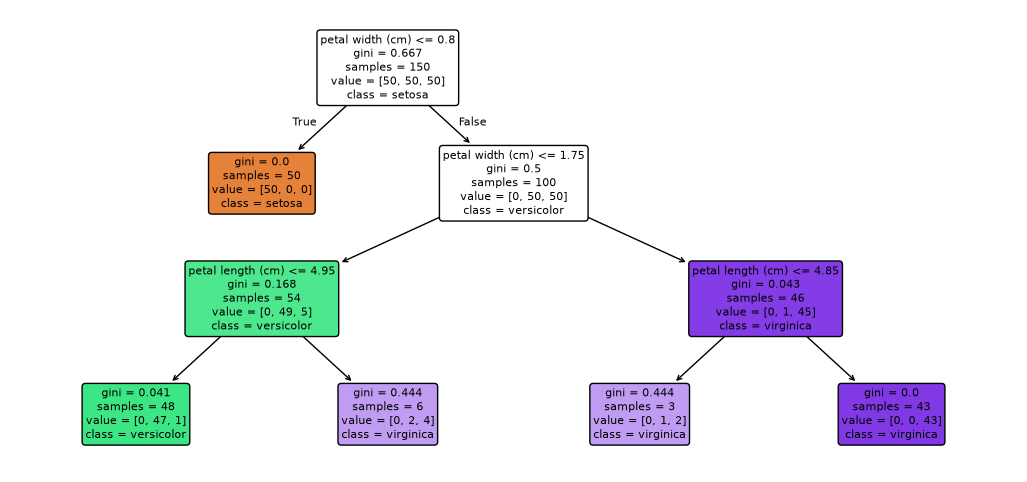

In [6]:
iris = load_iris()
tree_iris = DecisionTreeClassifier(max_depth=3, random_state=0).fit(iris.data, iris.target)
fig, ax = plt.subplots(figsize=(13, 6))
plot_tree(tree_iris, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=8, ax=ax)
plt.show()

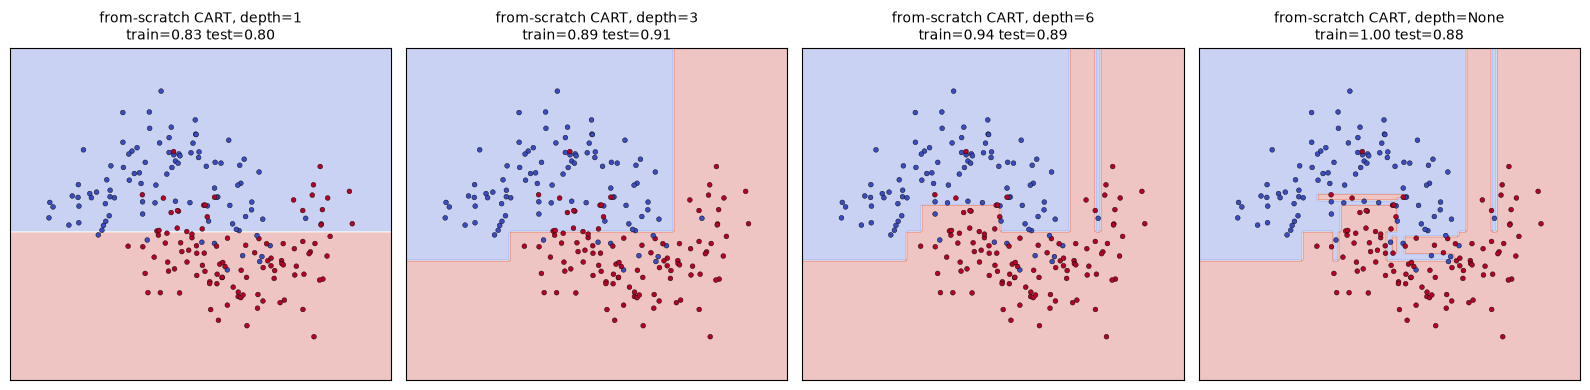

In [7]:
def plot_boundary(ax, model, X, y, title, h=250):
    x0 = np.linspace(X[:, 0].min() - .5, X[:, 0].max() + .5, h)
    x1 = np.linspace(X[:, 1].min() - .5, X[:, 1].max() + .5, h)
    XX, YY = np.meshgrid(x0, x1)
    Z = model.predict(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)
    ax.contourf(XX, YY, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=12, edgecolor="k", linewidth=0.3)
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])

Xm, ym = make_moons(n_samples=400, noise=0.3, random_state=0)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.5, random_state=0)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, depth in zip(axes, [1, 3, 6, None]):
    m = CARTClassifier(max_depth=depth).fit(Xm_tr, ym_tr)
    plot_boundary(ax, m, Xm_tr, ym_tr,
                  f"from-scratch CART, depth={depth}\ntrain={accuracy_score(ym_tr, m.predict(Xm_tr)):.2f} "
                  f"test={accuracy_score(ym_te, m.predict(Xm_te)):.2f}", h=150)
plt.tight_layout(); plt.show()

## 4. Overfitting and cost-complexity pruning

A fully grown tree has low bias but very high variance: small changes in the data change the top splits and hence the whole tree. Two remedies:

- **Pre-pruning** (early stopping): `max_depth`, `min_samples_leaf`, `min_impurity_decrease`. Simple but myopic — a weak split may enable strong splits below it (think XOR).
- **Post-pruning**: grow a large tree $T_0$, then prune back. **Minimal cost-complexity pruning** minimises
$$
R_\alpha(T) = R(T) + \alpha\,|T|,
$$
where $R(T)$ is the total (sample-weighted) impurity of the leaves and $|T|$ the number of leaves. For an internal node $t$ with subtree $T_t$, pruning $T_t$ to a leaf is worthwhile once
$$
\alpha \ge g(t) = \frac{R(t) - R(T_t)}{|T_t| - 1}.
$$
*Weakest-link pruning* repeatedly collapses the node with smallest $g(t)$, producing a nested sequence of subtrees $T_0\supset T_1\supset\dots\supset\{\text{root}\}$ with increasing effective $\alpha$. Breiman et al. showed that each $T_{\alpha}$ in this sequence is the optimal subtree for its $\alpha$. We choose $\alpha$ by cross-validation.

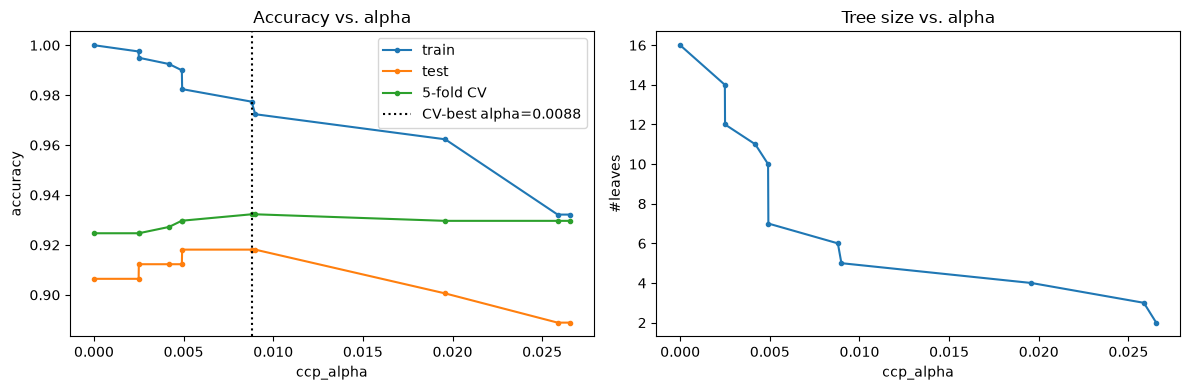

pruned tree: 6 leaves, test acc = 0.918


In [8]:
path = DecisionTreeClassifier(random_state=0).cost_complexity_pruning_path(Xtr, ytr)
alphas = path.ccp_alphas[:-1]                    # the last alpha prunes to the root
tr_acc, te_acc, cv_acc, leaves = [], [], [], []
for a in alphas:
    t = DecisionTreeClassifier(random_state=0, ccp_alpha=a).fit(Xtr, ytr)
    tr_acc.append(t.score(Xtr, ytr)); te_acc.append(t.score(Xte, yte)); leaves.append(t.get_n_leaves())
    cv_acc.append(cross_val_score(DecisionTreeClassifier(random_state=0, ccp_alpha=a), Xtr, ytr, cv=5).mean())

best_alpha = alphas[int(np.argmax(cv_acc))]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(alphas, tr_acc, "o-", label="train", ms=3); axes[0].plot(alphas, te_acc, "o-", label="test", ms=3)
axes[0].plot(alphas, cv_acc, "o-", label="5-fold CV", ms=3)
axes[0].axvline(best_alpha, color="k", ls=":", label=f"CV-best alpha={best_alpha:.4f}")
axes[0].set_xlabel("ccp_alpha"); axes[0].set_ylabel("accuracy"); axes[0].legend(); axes[0].set_title("Accuracy vs. alpha")
axes[1].plot(alphas, leaves, "o-", ms=3); axes[1].set_xlabel("ccp_alpha"); axes[1].set_ylabel("#leaves")
axes[1].set_title("Tree size vs. alpha")
plt.tight_layout(); plt.show()
pruned = DecisionTreeClassifier(random_state=0, ccp_alpha=best_alpha).fit(Xtr, ytr)
print(f"pruned tree: {pruned.get_n_leaves()} leaves, test acc = {pruned.score(Xte, yte):.3f}")

## 5. Bagging and variance reduction

**Bootstrap aggregating** (Breiman, 1996): draw $B$ bootstrap samples (size $n$, with replacement), fit a high-variance base learner $\hat f_b$ on each, and average: $\hat f_{\text{bag}}(\mathbf{x}) = \frac1B\sum_b \hat f_b(\mathbf{x})$ (majority vote or probability averaging for classification).

**Variance math.** Suppose the $\hat f_b(\mathbf{x})$ are identically distributed with variance $\sigma^2$ and pairwise correlation $\rho$. Then
$$
\operatorname{Var}\Big(\frac1B\sum_{b=1}^B \hat f_b\Big) = \frac{1}{B^2}\Big(B\sigma^2 + B(B-1)\rho\sigma^2\Big) = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2 .
$$
- The second term vanishes as $B\to\infty$: **adding trees never hurts** (no overfitting in $B$).
- The first term, $\rho\sigma^2$, is a floor: averaging cannot remove variance shared by all models. Bagged trees on the same data are highly correlated because strong predictors dominate the top splits.
- The bias is unchanged: $\mathbb E[\hat f_{\text{bag}}] = \mathbb E[\hat f_b]$. So bagging helps **low-bias, high-variance** learners (deep trees), not stable ones (linear models, $k$-NN with large $k$).

**Out-of-bag samples.** The probability that a given sample is *not* in a bootstrap sample is $(1-1/n)^n\to e^{-1}\approx0.368$. Each point is thus OOB for about a third of the trees; predicting it with only those trees gives a nearly free estimate of generalisation error.

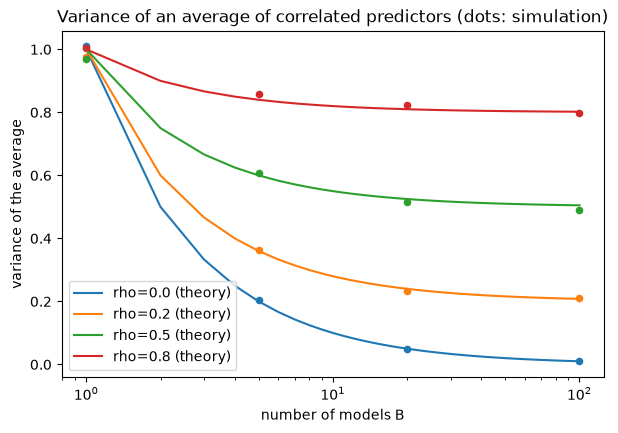

In [9]:
# Empirical check of the variance formula: rho*sigma^2 + (1-rho)/B*sigma^2
sigma2 = 1.0
B = np.arange(1, 101)
fig, ax = plt.subplots()
for rho in [0.0, 0.2, 0.5, 0.8]:
    ax.plot(B, rho * sigma2 + (1 - rho) / B * sigma2, label=f"rho={rho} (theory)")
    # simulate: equicorrelated Gaussians Z_b = sqrt(rho)*S + sqrt(1-rho)*E_b
    sims = []
    for b in [1, 5, 20, 100]:
        S = rng.normal(size=(4000, 1)); E = rng.normal(size=(4000, b))
        sims.append((b, (np.sqrt(rho) * S + np.sqrt(1 - rho) * E).mean(1).var()))
    ax.scatter(*zip(*sims), s=20)
ax.set_xscale("log"); ax.set_xlabel("number of models B"); ax.set_ylabel("variance of the average")
ax.set_title("Variance of an average of correlated predictors (dots: simulation)"); ax.legend(); plt.show()

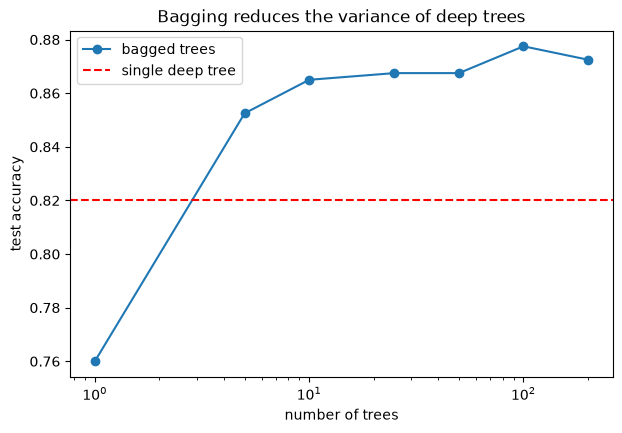

In [10]:
# Bagging deep trees: variance of predictions across training sets and accuracy
Xc, yc = make_classification(n_samples=1000, n_features=20, n_informative=8, flip_y=0.05, random_state=1)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.4, random_state=0)
res = []
for B_ in [1, 5, 10, 25, 50, 100, 200]:
    bag = BaggingClassifier(DecisionTreeClassifier(), n_estimators=B_, random_state=0, n_jobs=-1).fit(Xc_tr, yc_tr)
    res.append((B_, bag.score(Xc_te, yc_te)))
tree_acc = DecisionTreeClassifier(random_state=0).fit(Xc_tr, yc_tr).score(Xc_te, yc_te)
plt.plot(*zip(*res), "o-", label="bagged trees"); plt.axhline(tree_acc, color="r", ls="--", label="single deep tree")
plt.xscale("log"); plt.xlabel("number of trees"); plt.ylabel("test accuracy"); plt.legend()
plt.title("Bagging reduces the variance of deep trees"); plt.show()

## 6. Random Forests: OOB error and feature importance

**Random Forests** (Breiman, 2001) = bagging + **feature subsampling**: at *each split*, only a random subset of `max_features` $= m$ features is considered (defaults: $m\approx\sqrt d$ for classification). This prevents dominant features from appearing at the top of every tree, **reducing the correlation $\rho$** in the variance formula at the cost of slightly increasing each tree's variance/bias. Smaller $m$ $\Rightarrow$ lower $\rho$.

### 6.1 OOB error vs. `max_features`

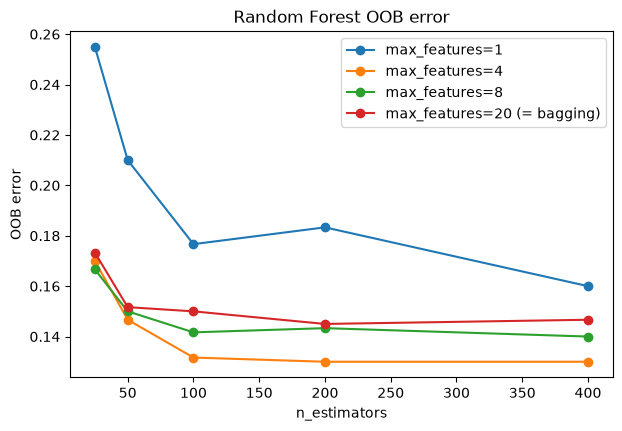

OOB accuracy = 0.870   held-out test accuracy = 0.902


In [11]:
d = Xc.shape[1]
fig, ax = plt.subplots()
for mf in [1, 4, 8, d]:
    errs = []
    ns = [25, 50, 100, 200, 400]
    for n_est in ns:
        rf = RandomForestClassifier(n_estimators=n_est, max_features=mf, oob_score=True,
                                    random_state=0, n_jobs=-1).fit(Xc_tr, yc_tr)
        errs.append(1 - rf.oob_score_)
    ax.plot(ns, errs, "o-", label=f"max_features={mf}" + (" (= bagging)" if mf == d else ""))
ax.set_xlabel("n_estimators"); ax.set_ylabel("OOB error"); ax.legend(); ax.set_title("Random Forest OOB error")
plt.show()
rf = RandomForestClassifier(n_estimators=400, oob_score=True, random_state=0, n_jobs=-1).fit(Xc_tr, yc_tr)
print(f"OOB accuracy = {rf.oob_score_:.3f}   held-out test accuracy = {rf.score(Xc_te, yc_te):.3f}")

The OOB estimate is close to the held-out accuracy without needing a separate validation set; it tends to be slightly pessimistic because each point is predicted by only about a third of the trees.

### 6.2 Feature importance: impurity-based vs. permutation

- **Mean Decrease in Impurity (MDI)**, `feature_importances_`: the total impurity reduction contributed by splits on feature $j$, weighted by the fraction of samples reaching each node, averaged over trees. Cheap, but computed **on training data** and **biased toward high-cardinality features** (continuous or many-category features offer more split points, so they can reduce training impurity by chance).
- **Permutation importance**: the drop in a held-out score when feature $j$ is randomly shuffled, breaking its relationship with $y$. Model-agnostic and evaluated on test data, but correlated features share (and can hide) importance.

To expose the MDI bias, we build a synthetic problem where the label depends only on **three low-cardinality (3-level) features**, and add two **pure-noise** columns: a continuous random feature (many possible split points) and a random binary feature.

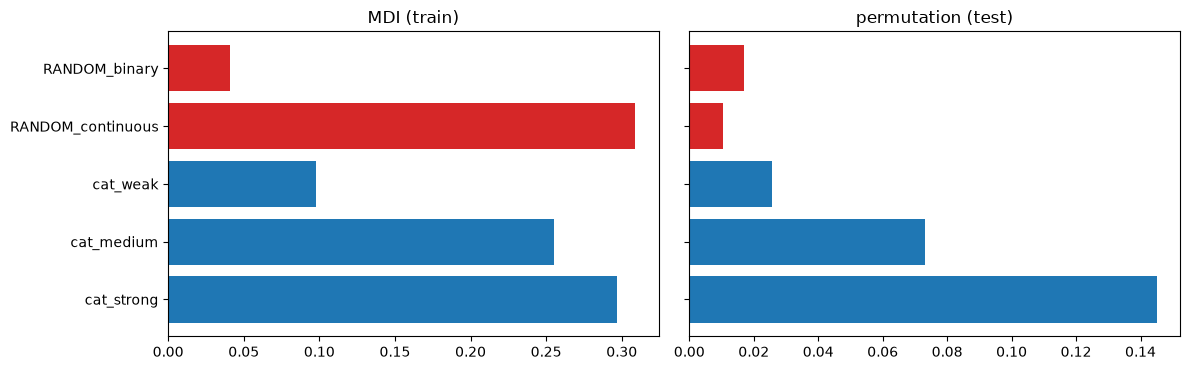

,MDI (train),permutation (test)
cat_strong,0.297,0.145
cat_medium,0.255,0.073
cat_weak,0.098,0.026
RANDOM_continuous,0.309,0.010
RANDOM_binary,0.041,0.017


In [12]:
rng_imp = np.random.default_rng(42)                         # local generator for reproducibility
n = 1500
Xcat = rng_imp.integers(0, 3, size=(n, 3))                         # informative, 3 levels each
logit = 1.2 * (Xcat[:, 0] - 1) + 1.0 * (Xcat[:, 1] - 1) + 0.6 * (Xcat[:, 2] - 1)
y_imp = (rng_imp.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
X_imp = np.c_[Xcat, rng_imp.normal(size=n), rng_imp.integers(0, 2, n)]
names = ["cat_strong", "cat_medium", "cat_weak", "RANDOM_continuous", "RANDOM_binary"]
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(X_imp, y_imp, test_size=0.3, random_state=0)
rf_imp = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=0, n_jobs=-1).fit(Xi_tr, yi_tr)
perm = permutation_importance(rf_imp, Xi_te, yi_te, n_repeats=20, random_state=0, n_jobs=-1)

imp = pd.DataFrame({"MDI (train)": rf_imp.feature_importances_,
                    "permutation (test)": perm.importances_mean}, index=names)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
colors = ["tab:red" if n_.startswith("RANDOM") else "tab:blue" for n_ in names]
for ax, col in zip(axes, imp.columns):
    ax.barh(names, imp[col], color=colors); ax.set_title(col)
plt.tight_layout(); plt.show()
imp.round(3)

The continuous noise feature receives an MDI importance as large as the strongest real feature: deep trees keep splitting on it to fit the training noise, and each such split "reduces impurity" on the training set. Its permutation importance on the test set is close to zero, and the ranking of the informative features is recovered. (With `min_samples_leaf=1` the MDI bias is even more extreme.) (With correlated features — e.g. radius/perimeter/area in breast cancer — permutation importance has its own problem: shuffling one feature leaves its correlated siblings intact, so each looks unimportant.)

## 7. AdaBoost: derivation and from-scratch implementation

**Boosting** combines many *weak* learners (slightly better than chance, high bias) *sequentially*, each focusing on the mistakes of the previous ones. It mainly reduces **bias**.

### 7.1 AdaBoost as forward stagewise additive modelling

Labels $y\in\{-1,+1\}$, additive model $F_M(\mathbf{x}) = \sum_{m=1}^M\alpha_m h_m(\mathbf{x})$ with $h_m\in\{-1,+1\}$, and **exponential loss** $L(y,F)=e^{-yF}$. At stage $m$ we add one term greedily:
$$
(\alpha_m, h_m) = \arg\min_{\alpha,h}\sum_{i=1}^n e^{-y_i(F_{m-1}(\mathbf{x}_i) + \alpha h(\mathbf{x}_i))}
= \arg\min_{\alpha,h}\sum_i w_i^{(m)} e^{-\alpha y_i h(\mathbf{x}_i)},
\qquad w_i^{(m)} = e^{-y_iF_{m-1}(\mathbf{x}_i)} .
$$
Split the sum by correct ($y_ih=1$) and incorrect ($y_ih=-1$) predictions, with normalised weights and weighted error $\varepsilon_m = \sum_i w_i\mathbb 1[y_i\ne h(\mathbf x_i)]/\sum_i w_i$:
$$
\sum_i w_i e^{-\alpha y_ih(\mathbf x_i)} \propto (1-\varepsilon_m)e^{-\alpha} + \varepsilon_m e^{\alpha}.
$$
- For any $\alpha>0$ this is minimised over $h$ by minimising $\varepsilon_m$: **fit $h_m$ to the weighted data**.
- Setting the derivative in $\alpha$ to zero: $-(1-\varepsilon_m)e^{-\alpha}+\varepsilon_me^{\alpha}=0\Rightarrow$
$$
\boxed{\alpha_m = \tfrac12\log\frac{1-\varepsilon_m}{\varepsilon_m}}
$$
- The new weights are $w_i^{(m+1)} = w_i^{(m)}e^{-\alpha_my_ih_m(\mathbf x_i)}$: misclassified points are multiplied by $e^{\alpha_m}=\sqrt{(1-\varepsilon_m)/\varepsilon_m}>1$, correct ones by $e^{-\alpha_m}$. After normalisation, the misclassified points carry exactly half the total weight, so $h_m$ has error $1/2$ under the new weights — the next learner is forced to be "different".

**Training error bound.** Since $\mathbb 1[yF<0]\le e^{-yF}$, the training error is at most $\prod_m 2\sqrt{\varepsilon_m(1-\varepsilon_m)}\le\exp(-2\sum_m\gamma_m^2)$ with $\gamma_m = \frac12-\varepsilon_m$: exponential decrease as long as each learner beats chance.

**Population minimiser.** $\arg\min_F\mathbb E[e^{-YF}\mid\mathbf x] = \frac12\log\frac{P(Y=1\mid\mathbf x)}{P(Y=-1\mid\mathbf x)}$ — half the log-odds, which links AdaBoost to logistic regression (Friedman, Hastie & Tibshirani, 2000).

In [13]:
class AdaBoostScratch:
    # Discrete AdaBoost with decision stumps (depth-1 trees) as weak learners. Labels in {-1, +1}.
    def __init__(self, n_estimators=200):
        self.n_estimators = n_estimators

    def fit(self, X, y):
        n = len(y)
        w = np.full(n, 1 / n)                          # initial uniform weights
        self.learners_, self.alphas_, self.errors_ = [], [], []
        for m in range(self.n_estimators):
            stump = DecisionTreeClassifier(max_depth=1).fit(X, y, sample_weight=w)
            pred = stump.predict(X)
            eps = np.clip(w[pred != y].sum() / w.sum(), 1e-12, 1 - 1e-12)   # weighted error
            if eps >= 0.5:                              # weak learner no better than chance
                break
            alpha = 0.5 * np.log((1 - eps) / eps)       # derived optimal step
            w = w * np.exp(-alpha * y * pred)           # up-weight mistakes, down-weight correct
            w /= w.sum()
            self.learners_.append(stump); self.alphas_.append(alpha); self.errors_.append(eps)
        return self

    def decision_function(self, X):
        return sum(a * h.predict(X) for a, h in zip(self.alphas_, self.learners_))

    def staged_decision_function(self, X):
        F = np.zeros(len(X))
        for a, h in zip(self.alphas_, self.learners_):
            F = F + a * h.predict(X)
            yield F

    def predict(self, X):
        return np.sign(self.decision_function(X))

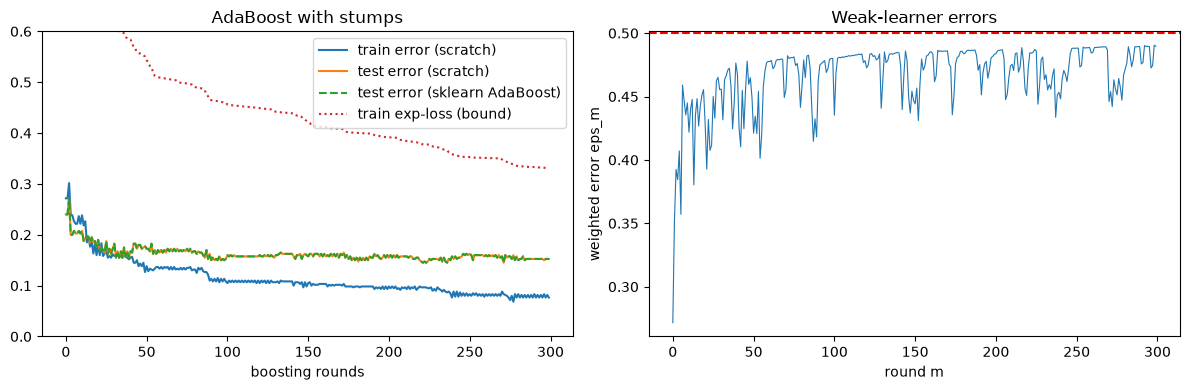

scratch test acc = 0.848   sklearn test acc = 0.848


In [14]:
ypm_tr, ypm_te = 2 * yc_tr - 1, 2 * yc_te - 1
ada = AdaBoostScratch(n_estimators=300).fit(Xc_tr, ypm_tr)
tr_err = [np.mean(np.sign(F) != ypm_tr) for F in ada.staged_decision_function(Xc_tr)]
te_err = [np.mean(np.sign(F) != ypm_te) for F in ada.staged_decision_function(Xc_te)]
exp_loss = [np.mean(np.exp(-ypm_tr * F)) for F in ada.staged_decision_function(Xc_tr)]

ada_sk = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=300, learning_rate=1.0,
                            random_state=0).fit(Xc_tr, yc_tr)
te_err_sk = [1 - accuracy_score(yc_te, p) for p in ada_sk.staged_predict(Xc_te)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(tr_err, label="train error (scratch)"); axes[0].plot(te_err, label="test error (scratch)")
axes[0].plot(te_err_sk, "--", label="test error (sklearn AdaBoost)"); axes[0].plot(exp_loss, ":", label="train exp-loss (bound)")
axes[0].set_ylim(0, 0.6); axes[0].set_xlabel("boosting rounds"); axes[0].legend(); axes[0].set_title("AdaBoost with stumps")
axes[1].plot(ada.errors_, lw=0.8); axes[1].axhline(0.5, color="r", ls="--")
axes[1].set_xlabel("round m"); axes[1].set_ylabel("weighted error eps_m"); axes[1].set_title("Weak-learner errors")
plt.tight_layout(); plt.show()
print(f"scratch test acc = {1 - te_err[-1]:.3f}   sklearn test acc = {ada_sk.score(Xc_te, yc_te):.3f}")

The exponential loss (an upper bound on training error) decreases monotonically. The weighted errors $\varepsilon_m$ creep toward $0.5$: later stumps focus on the hardest points. The test error often keeps decreasing even after training error plateaus — explained by the growth of the **margins** $y_iF(\mathbf x_i)/\sum_m\alpha_m$ (Schapire et al., 1998), a connection with Lecture 06.

## 8. Gradient boosting as functional gradient descent

AdaBoost's derivation is specific to exponential loss. **Gradient boosting** (Friedman, 2001) generalises it to any differentiable loss $L(y, F)$.

View the training objective as a function of the vector of predictions $\mathbf F = (F(\mathbf x_1),\dots,F(\mathbf x_n))$:
$\mathcal{J}(\mathbf F)=\sum_iL(y_i,F(\mathbf x_i))$. Gradient descent in this "function space" would update $\mathbf F\leftarrow\mathbf F-\nu\nabla\mathcal J$. But the gradient is only defined at training points, so we **approximate the negative gradient with a regression tree** that generalises to new $\mathbf x$:

1. Initialise $F_0(\mathbf x)=\arg\min_c\sum_iL(y_i,c)$ (the mean for squared loss).
2. For $m=1,\dots,M$:
   - compute **pseudo-residuals** $r_{im} = -\left[\frac{\partial L(y_i,F(\mathbf x_i))}{\partial F(\mathbf x_i)}\right]_{F=F_{m-1}}$;
   - fit a regression tree $h_m$ to $\{(\mathbf x_i, r_{im})\}$ (least squares);
   - (optionally) re-optimise each leaf value: $\gamma_{jm}=\arg\min_\gamma\sum_{\mathbf x_i\in R_{jm}}L(y_i,F_{m-1}(\mathbf x_i)+\gamma)$;
   - update $F_m = F_{m-1}+\nu\,h_m$ with **learning rate (shrinkage)** $\nu\in(0,1]$.

| loss | $L(y,F)$ | pseudo-residual $r$ |
|---|---|---|
| squared | $\frac12(y-F)^2$ | $y-F$ (ordinary residual) |
| absolute | $\lvert y-F\rvert$ | $\operatorname{sign}(y-F)$ |
| logistic ($y\in\{0,1\}$) | $-[y\log p+(1-y)\log(1-p)]$, $p=\sigma(F)$ | $y-p$ |

Regularisation knobs: small $\nu$ (with more trees), shallow trees (depth 2–8), row subsampling (*stochastic* gradient boosting), and early stopping on a validation set. Unlike bagging, **more trees can overfit**.

In [15]:
class GBMRegressorScratch:
    # Gradient boosting for regression; base learners are sklearn regression trees.
    def __init__(self, n_estimators=200, learning_rate=0.1, max_depth=3, loss="squared", subsample=1.0, seed=0):
        self.n_estimators, self.learning_rate, self.max_depth = n_estimators, learning_rate, max_depth
        self.loss, self.subsample, self.seed = loss, subsample, seed

    def _neg_gradient(self, y, F):
        return y - F if self.loss == "squared" else np.sign(y - F)

    def fit(self, X, y):
        rng = np.random.default_rng(self.seed)
        self.F0_ = y.mean() if self.loss == "squared" else np.median(y)   # optimal constant
        F = np.full(len(y), self.F0_)
        self.trees_ = []
        for m in range(self.n_estimators):
            r = self._neg_gradient(y, F)                           # pseudo-residuals
            idx = rng.random(len(y)) < self.subsample              # stochastic GB row subsampling
            tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=m).fit(X[idx], r[idx])
            if self.loss == "absolute":
                # leaf re-optimisation: median of the raw residuals in each leaf is optimal for L1
                leaves = tree.apply(X)
                for leaf in np.unique(leaves):
                    tree.tree_.value[leaf, 0, 0] = np.median((y - F)[leaves == leaf])
            F = F + self.learning_rate * tree.predict(X)           # functional gradient step
            self.trees_.append(tree)
        return self

    def staged_predict(self, X):
        F = np.full(len(X), self.F0_)
        for t in self.trees_:
            F = F + self.learning_rate * t.predict(X)
            yield F

    def predict(self, X):
        *_, F = self.staged_predict(X)
        return F

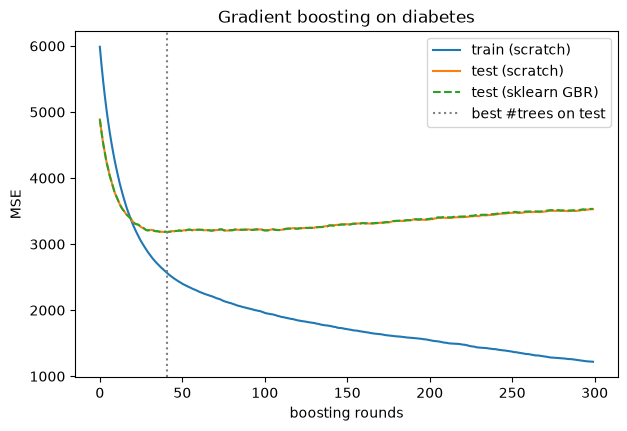

scratch test MSE = 3529.1   sklearn test MSE = 3533.9   max |pred diff| = 6.57e+00


In [16]:
Xd, yd = load_diabetes(return_X_y=True)
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, test_size=0.3, random_state=0)
params = dict(n_estimators=300, learning_rate=0.05, max_depth=2)
gbm = GBMRegressorScratch(**params).fit(Xd_tr, yd_tr)
gbm_sk = GradientBoostingRegressor(**params, random_state=0).fit(Xd_tr, yd_tr)

mse_tr = [mean_squared_error(yd_tr, F) for F in gbm.staged_predict(Xd_tr)]
mse_te = [mean_squared_error(yd_te, F) for F in gbm.staged_predict(Xd_te)]
mse_te_sk = [mean_squared_error(yd_te, F) for F in gbm_sk.staged_predict(Xd_te)]
plt.plot(mse_tr, label="train (scratch)"); plt.plot(mse_te, label="test (scratch)")
plt.plot(mse_te_sk, "--", label="test (sklearn GBR)")
plt.axvline(int(np.argmin(mse_te)), color="gray", ls=":", label="best #trees on test")
plt.xlabel("boosting rounds"); plt.ylabel("MSE"); plt.legend(); plt.title("Gradient boosting on diabetes")
plt.show()
print(f"scratch test MSE = {mse_te[-1]:.1f}   sklearn test MSE = {mse_te_sk[-1]:.1f}   "
      f"max |pred diff| = {np.abs(gbm.predict(Xd_te) - gbm_sk.predict(Xd_te)).max():.2e}")

With squared loss our implementation closely matches sklearn's `GradientBoostingRegressor`. The test curve shows the typical U-shape: after some point additional trees fit noise, which is why **early stopping** matters.

### 8.1 Effect of shrinkage

Smaller learning rates need more trees but usually generalise better — each step is a more conservative move along the functional gradient (akin to $\ell_1$-regularised path following; see ESL §10.12).

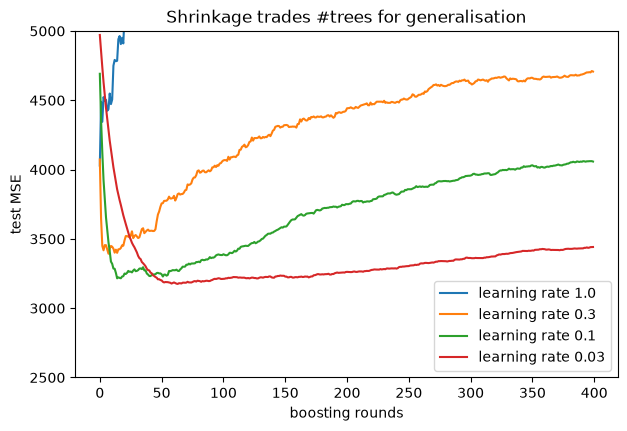

In [17]:
fig, ax = plt.subplots()
for lr in [1.0, 0.3, 0.1, 0.03]:
    g = GBMRegressorScratch(n_estimators=400, learning_rate=lr, max_depth=2).fit(Xd_tr, yd_tr)
    ax.plot([mean_squared_error(yd_te, F) for F in g.staged_predict(Xd_te)], label=f"learning rate {lr}")
ax.set_ylim(2500, 5000); ax.set_xlabel("boosting rounds"); ax.set_ylabel("test MSE"); ax.legend()
ax.set_title("Shrinkage trades #trees for generalisation"); plt.show()

## 9. HistGradientBoosting, voting and stacking

### 9.1 Histogram-based gradient boosting

`HistGradientBoostingClassifier/Regressor` (inspired by LightGBM) bins each feature into at most 255 quantile bins. Split finding then costs $O(\#\text{bins})$ per feature using gradient histograms instead of $O(n\log n)$ sorting, and the histogram of one child is obtained by subtracting the sibling's from the parent's. It also uses second-order (Newton) leaf values as in XGBoost:
$$
\gamma_j = -\frac{\sum_{i\in R_j}g_i}{\sum_{i\in R_j}h_i + \lambda},\qquad g_i=\partial_FL,\; h_i=\partial_F^2L,
$$
supports missing values natively, and has built-in early stopping. It is the default choice for tabular data with $n\gtrsim10^4$.

### 9.2 Voting and stacking

- **Voting**: average the predictions (hard = majority vote, soft = average probabilities) of diverse models. Works when models are accurate *and* make different errors.
- **Stacking** (Wolpert, 1992): train a *meta-learner* on the **out-of-fold** predictions of base models, learning how much to trust each. Using out-of-fold predictions (cross-validation) is essential; otherwise the meta-learner sees overfitted in-sample predictions.

In [18]:
Xbig, ybig = make_classification(n_samples=10000, n_features=30, n_informative=12, random_state=0)
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xbig, ybig, test_size=0.3, random_state=0)
for name, m in [("GradientBoostingClassifier", GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=0)),
                ("HistGradientBoostingClassifier", HistGradientBoostingClassifier(max_iter=100, random_state=0))]:
    t0 = time.perf_counter(); m.fit(Xb_tr, yb_tr); t = time.perf_counter() - t0
    print(f"{name:32s}: fit time {t:5.2f}s   test acc {m.score(Xb_te, yb_te):.3f}")

GradientBoostingClassifier      : fit time  6.17s   test acc 0.867


HistGradientBoostingClassifier  : fit time  0.48s   test acc 0.934


## 10. Comparison table

We compare all models on the breast cancer data with 5-fold cross-validation (scale-sensitive models inside pipelines).

In [19]:
base = [("lr", make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))),
        ("knn", make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15))),
        ("rf", RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1))]
models = {
    "Decision tree (full)": DecisionTreeClassifier(random_state=0),
    "Decision tree (pruned)": DecisionTreeClassifier(random_state=0, ccp_alpha=best_alpha),
    "Bagging (100 trees)": BaggingClassifier(DecisionTreeClassifier(), n_estimators=100, random_state=0, n_jobs=-1),
    "Random forest (300)": RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1),
    "AdaBoost (stumps, 200)": AdaBoostClassifier(n_estimators=200, random_state=0),
    "Gradient boosting": GradientBoostingClassifier(random_state=0),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=0),
    "Soft voting (LR+kNN+RF)": VotingClassifier(base, voting="soft"),
    "Stacking (LR+kNN+RF -> LR)": StackingClassifier(base, final_estimator=LogisticRegression(), cv=5),
}
rows = []
for name, m in models.items():
    t0 = time.perf_counter()
    s = cross_val_score(m, Xbc, ybc, cv=5, n_jobs=1)
    rows.append({"model": name, "CV accuracy": s.mean(), "std": s.std(), "time (s)": time.perf_counter() - t0})
pd.DataFrame(rows).set_index("model").round(3).sort_values("CV accuracy", ascending=False)

,CV accuracy,std,time (s)
model,,,
"AdaBoost (stumps, 200)",0.977,0.009,2.954
Stacking (LR+kNN+RF -> LR),0.977,0.009,13.180
Soft voting (LR+kNN+RF),0.975,0.015,2.239
HistGradientBoosting,0.965,0.018,0.775
Random forest (300),0.963,0.022,3.238
Gradient boosting,0.963,0.021,1.721
Bagging (100 trees),0.958,0.029,1.390
Decision tree (pruned),0.926,0.020,0.040
Decision tree (full),0.917,0.016,0.041


Typical pattern: a single tree is clearly worst; all ensembles give large gains; differences between the top models are within one standard deviation — on small data, **the choice among good ensembles matters less than careful validation**.

| method | reduces | base learners | parallel? | key hyperparameters |
|---|---|---|---|---|
| Bagging | variance | deep trees | yes | `n_estimators` |
| Random forest | variance (decorrelation) | deep trees | yes | `max_features`, `min_samples_leaf` |
| AdaBoost | bias | stumps / shallow trees | no | `n_estimators`, `learning_rate` |
| Gradient boosting | bias (and variance via shrinkage) | shallow trees | no (per tree) | `learning_rate`, `n_estimators`, `max_depth`, `subsample` |
| Stacking | both | heterogeneous | yes | choice of base models, meta-learner |

## 11. Pitfalls & practical tips

- **Trees do not need feature scaling**, and are invariant to monotone transformations of features — but they cannot extrapolate beyond the training range (predictions are piecewise constant).
- **Axis-aligned splits** struggle with diagonal boundaries (staircases); rotated or engineered features can help.
- **Unpruned single trees overfit**; if you need one interpretable tree, prune with `ccp_alpha` chosen by CV.
- **Random forests are robust defaults**: `n_estimators` just needs to be "large enough" (monitor OOB); tune `max_features` and `min_samples_leaf`.
- **Boosting can overfit**: tune `learning_rate` and the number of trees *together*, with early stopping (`n_iter_no_change` / `early_stopping=True`).
- **Do not trust MDI feature importances** for inference; prefer permutation importance on held-out data, and be careful with correlated features (consider grouping them), or use SHAP values.
- **Class imbalance**: use `class_weight` or sample weights; evaluate with appropriate metrics.
- **Stacking must use out-of-fold predictions**; `StackingClassifier` does this via its `cv` argument.
- **AdaBoost is sensitive to label noise** — exponential loss assigns huge weights to mislabeled points. Gradient boosting with logistic or Huber loss is more robust.

## 12. Exercises

**Exercise 1 (pen & paper — impurity).** (a) Show that the two-class Gini index $2p(1-p)$ and entropy are strictly concave in $p$. (b) Use concavity (Jensen) to prove that the weighted impurity of children never exceeds the parent's impurity. (c) Give an example of a split that reduces Gini but not the misclassification rate.

**Exercise 2 (pen & paper — bagging).** (a) Derive $\operatorname{Var}(\bar f)=\rho\sigma^2+\frac{1-\rho}{B}\sigma^2$. (b) Show that the probability a given sample appears in a bootstrap sample tends to $1-e^{-1}$. (c) Why doesn't bagging help ordinary least squares much?

**Exercise 3 (pen & paper — boosting).** (a) Show that after AdaBoost's reweighting, the weak learner $h_m$ has weighted error exactly $1/2$. (b) Derive the pseudo-residuals and the optimal Newton leaf value for the logistic loss $L(y,F)=\log(1+e^{-yF})$, $y\in\{-1,+1\}$.

**Exercise 4 (coding — regression tree).** Extend `CARTClassifier` into a `CARTRegressor` using the MSE criterion (hint: with prefix sums of $y$ and $y^2$, the SSE of every candidate split is computable in $O(n)$). Compare with `DecisionTreeRegressor` on `load_diabetes`.

**Exercise 5 (coding — gradient boosting for classification).** Implement binary gradient boosting with logistic loss: initialise $F_0=\log\frac{\bar y}{1-\bar y}$, fit trees to $y-\sigma(F)$, and use Newton leaf values $\sum r_i/\sum p_i(1-p_i)$. Compare with `GradientBoostingClassifier` on breast cancer.

**Exercise 6 (coding — random forest from scratch).** Build a random forest from your `CARTClassifier` by adding a `max_features` argument (random feature subset at each split) and bootstrap sampling. Implement OOB accuracy and compare it with `RandomForestClassifier`.

In [20]:
# Exercise 4 — TODO: regression tree with the MSE criterion
class CARTRegressor:
    def __init__(self, max_depth=None, min_samples_leaf=1):
        self.max_depth, self.min_samples_leaf = max_depth, min_samples_leaf

    def fit(self, X, y):
        # TODO: grow the tree recursively; leaves store the mean of y
        return self

    def predict(self, X):
        # TODO: traverse the tree for each row
        return None

In [21]:
# Exercise 5 — TODO: gradient boosting with logistic loss
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

class GBMClassifierScratch:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators, self.learning_rate, self.max_depth = n_estimators, learning_rate, max_depth

    def fit(self, X, y):
        # TODO: F0 = log-odds of the base rate; loop: r = y - sigmoid(F); fit tree; Newton leaf values
        pass

    def predict_proba(self, X):
        # TODO
        pass

## 13. Summary

- Trees split greedily to reduce **impurity** (Gini, entropy, MSE); they are interpretable, scale-free, but high-variance.
- **Cost-complexity pruning** yields a nested family of subtrees indexed by $\alpha$, chosen by CV.
- **Bagging** reduces variance: $\operatorname{Var} = \rho\sigma^2 + (1-\rho)\sigma^2/B$. **Random forests** also reduce the correlation $\rho$ via feature subsampling; OOB error gives free validation.
- **MDI importances are biased**; permutation importance on held-out data is more trustworthy.
- **AdaBoost** is forward stagewise additive modelling with exponential loss: $\alpha_m=\frac12\log\frac{1-\varepsilon_m}{\varepsilon_m}$, multiplicative reweighting.
- **Gradient boosting** fits trees to the negative gradient of any differentiable loss — gradient descent in function space; shrinkage and early stopping are key.
- **Histogram GBMs** (LightGBM/XGBoost-style) are the state of the art for tabular data; **stacking/voting** combine heterogeneous models.

## Further reading

- ESL (Hastie, Tibshirani & Friedman), Ch. 9.2 (trees), 8.7 (bagging), 10 (boosting), 15 (random forests), 16 (ensembles).
- ISLR/ISLP (James et al.), Ch. 8.
- Bishop PRML, Ch. 14 (combining models).
- Murphy PML, Ch. 18 (trees, forests, bagging, boosting).
- Géron, *Hands-On Machine Learning*, Ch. 6–7.
- Breiman, Friedman, Olshen & Stone, *Classification and Regression Trees*, 1984.
- Breiman, "Bagging predictors", *Machine Learning*, 1996; "Random forests", *Machine Learning*, 2001.
- Freund & Schapire, "A decision-theoretic generalization of on-line learning and an application to boosting", 1997.
- Friedman, Hastie & Tibshirani, "Additive logistic regression: a statistical view of boosting", *Ann. Statist.*, 2000.
- Friedman, "Greedy function approximation: a gradient boosting machine", *Ann. Statist.*, 2001.
- Chen & Guestrin, "XGBoost", KDD 2016; Ke et al., "LightGBM", NeurIPS 2017.
- Strobl et al., "Bias in random forest variable importance measures", *BMC Bioinformatics*, 2007.